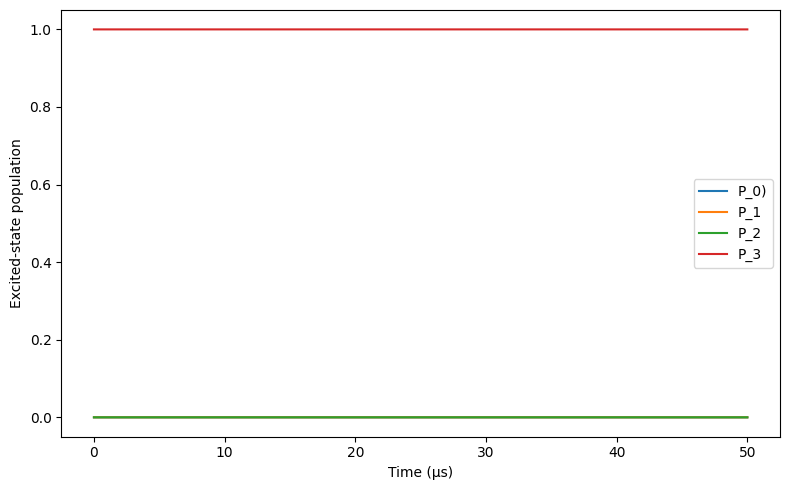

In [19]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# ============================================================
# 1) Basic single-spin operators
#    Spin-1/2 operators: S = sigma/2
# ============================================================
I2 = qt.qeye(2)

sx = 0.5 * qt.sigmax()
sy = 0.5 * qt.sigmay()
sz = 0.5 * qt.sigmaz()

# Lowering operator for relaxation channels
sm = qt.sigmam()

# ============================================================
# 2) Tensor-product operators
#    Order of subsystems: [Er, W1, W2]
# ============================================================

# Er spin operators
Sx = qt.tensor(sx, I2, I2)
Sy = qt.tensor(sy, I2, I2)
Sz = qt.tensor(sz, I2, I2)
Sm_e = qt.tensor(sm, I2, I2)

# Tungsten 1 spin operators
I1x = qt.tensor(I2, sx, I2)
I1y = qt.tensor(I2, sy, I2)
I1z = qt.tensor(I2, sz, I2)
Sm_1 = qt.tensor(I2, sm, I2)

# Tungsten 2 spin operators
I2x_op = qt.tensor(I2, I2, sx)
I2y_op = qt.tensor(I2, I2, sy)
I2z_op = qt.tensor(I2, I2, sz)
Sm_2 = qt.tensor(I2, I2, sm)

# ============================================================
# 3) Parameters
#    Everything in angular frequency units (rad/s)
# ============================================================
pi = np.pi


electron_freq = 7_738_167_000*2 * pi
raman_detuning = -400e3*2 * pi
Omega_detuned = 9.73e3*2 * pi


# Zeeman splittings
omega_e = electron_freq
omega_1 = 2 * pi * 756e3
omega_2 = 2 * pi * 764e3

# Hyperfine couplings
A1_par  = 38.5 * 2 * pi * 1e3
A1_perp = 60 * 2 * pi * 1e3

A2_par  = 12.5 * 2 * pi * 1e3
A2_perp = 9 * 2 * pi * 1e3

# ============================================================
# 4) Hamiltonian
# ============================================================
H_Z = omega_e * Sz + omega_1 * I1z + omega_2 * I2z_op

H_hf1 = A1_par * Sz * I1z + A1_perp * (Sx * I1x + Sy * I1y)
H_hf2 = A2_par * Sz * I2z_op + A2_perp * (Sx * I2x_op + Sy * I2y_op)

H0 = H_Z + H_hf1 + H_hf2

H_drive = Sx

def drive_coeff(t, args):
    return 2.0 * args["Omega"] * np.cos(args["omega_d1"] * t ) + 2.0 * args["Omega"] * np.cos(args["omega_d2"] * t) + 2.0 * args["Omega_detuned"] * np.cos(args["omega_d3"] * t)

H = [H0, [H_drive, drive_coeff]]



args = {
    "Omega": 243e3*2 * pi,
    "omega_d1": electron_freq + raman_detuning,
    "omega_d2": electron_freq + omega_1 + A1_par/2 + raman_detuning,
    "omega_d3": electron_freq + 75e3*2 * pi,
    "Omega_detuned": Omega_detuned,
}

# ============================================================
# 5) Basis states and initial state
#    Convention here:
#      g = basis(2,0)
#      e = basis(2,1)
# ============================================================
g = qt.basis(2, 0)
e = qt.basis(2, 1)

# Example initial state: |e, g, g>
psi0 = qt.tensor(e, g, g)
rho0 = qt.ket2dm(psi0)

# ============================================================
# 6) Optional Lindblad channels
# ============================================================
# Example coherence times
T1_e   = 1e-3
Tphi_e = 50e-6

T1_1   = 10000
Tphi_1 = 1.5

T1_2   = 10000
Tphi_2 = 1.5

c_ops = []

# Relaxation channels: L = sqrt(1/T1) * sigma_-
if T1_e > 0:
    c_ops.append(np.sqrt(1.0 / T1_e) * Sm_e)
if T1_1 > 0:
    c_ops.append(np.sqrt(1.0 / T1_1) * Sm_1)
if T1_2 > 0:
    c_ops.append(np.sqrt(1.0 / T1_2) * Sm_2)

# Pure dephasing channels: L = sqrt(1/(2*Tphi)) * sigma_z
# Since sz = sigma_z/2 here, use full Pauli-z operators for dephasing
SigmaZ_e = qt.tensor(qt.sigmaz(), I2, I2)
SigmaZ_1 = qt.tensor(I2, qt.sigmaz(), I2)
SigmaZ_2 = qt.tensor(I2, I2, qt.sigmaz())

if Tphi_e > 0:
    c_ops.append(np.sqrt(1.0 / (2.0 * Tphi_e)) * SigmaZ_e)
if Tphi_1 > 0:
    c_ops.append(np.sqrt(1.0 / (2.0 * Tphi_1)) * SigmaZ_1)
if Tphi_2 > 0:
    c_ops.append(np.sqrt(1.0 / (2.0 * Tphi_2)) * SigmaZ_2)

# ============================================================
# 7) Observables
# ============================================================
Proj_e_2 = qt.tensor(I2, e * e.dag(), e * e.dag())
Proj_e_1 = qt.tensor(I2, e * e.dag(), g * g.dag())
Proj_e_0 = qt.tensor(I2, g * g.dag(), e * e.dag())
Proj_e_3 = qt.tensor(I2, g * g.dag(), g * g.dag())

e_ops = [
    Proj_e_0,
    Proj_e_1,
    Proj_e_2,
    Proj_e_3,
]

# ============================================================
# 8) Time evolution
# ============================================================
tlist = np.linspace(0, 50e-6, 40000)

result = qt.mesolve(H, rho0, tlist, c_ops, e_ops=e_ops, args = args)

# ============================================================
# 9) Plot populations
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(tlist * 1e6, result.expect[0], label="P_0)")
plt.plot(tlist * 1e6, result.expect[1], label="P_1")
plt.plot(tlist * 1e6, result.expect[2], label="P_2")
plt.plot(tlist * 1e6, result.expect[3], label="P_3")
plt.xlabel("Time (µs)")
plt.ylabel("Excited-state population")
plt.legend()
plt.tight_layout()
plt.show()

